Step 1: Using Python to generate and clean multi-source operational data...
Step 2: Loading data into SQL Database for transformation...


,Factory,Total_Production,Avg_Defect_Rate,Total_Logistics_Cost
0,Delhi Plant,575680,2.783114,5758403
1,Panipat Plant,500621,2.714297,5155987
2,Surat Plant,450570,2.869299,4798850


Step 3: Generating Operational Dashboard visuals...


/tmp/ipykernel_10397/783180909.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], x='Factory', y='Total_Production', data=kpi_df, palette='Blues_d')
/tmp/ipykernel_10397/783180909.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], x='Factory', y='Avg_Defect_Rate', data=kpi_df, palette='Reds_d')
/tmp/ipykernel_10397/783180909.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[2], x='Factory', y='Total_Logistics_Cost', data=kpi_df, palette='Greens_d')


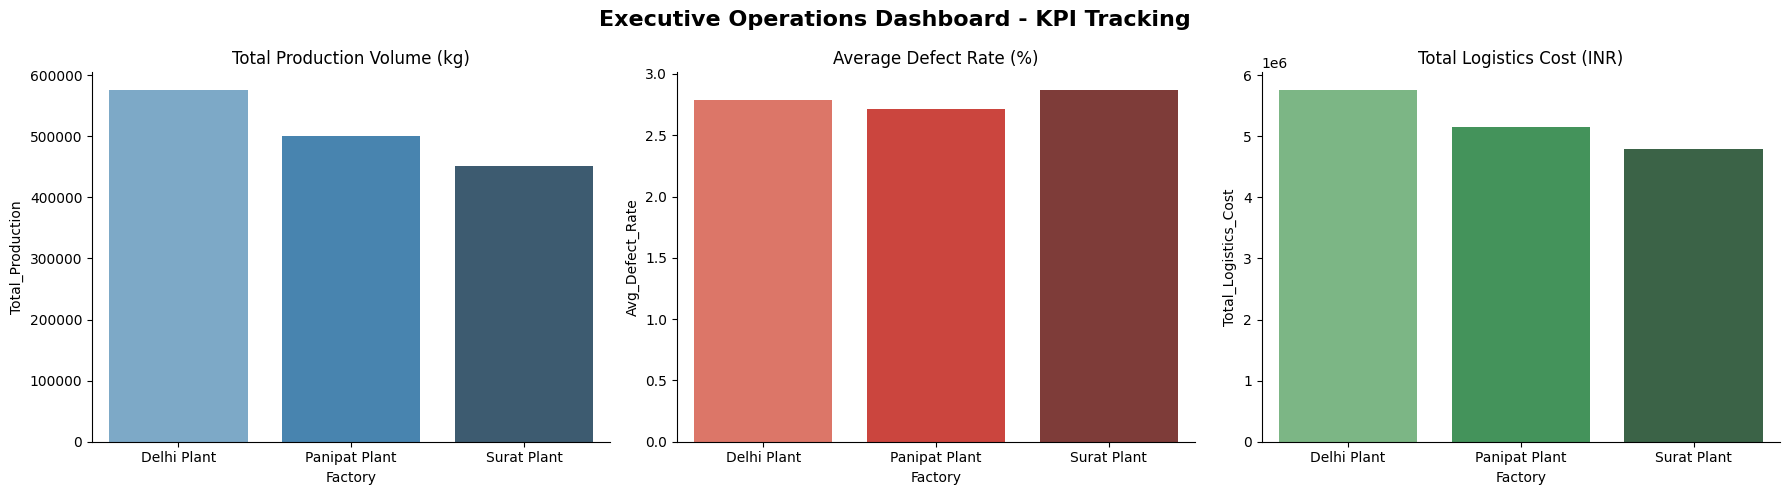

Pipeline Complete! Data saved to 'operations_data_clean.csv' for Power BI.


In [1]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

print("Step 1: Using Python to generate and clean multi-source operational data...")

# 1. Generate realistic Textile Operations Data
np.random.seed(42)
dates = [datetime(2025, 1, 1) + timedelta(days=i) for i in range(100)]
factories = ['Delhi Plant', 'Panipat Plant', 'Surat Plant']

data = {
    'Date': np.random.choice(dates, 500),
    'Factory': np.random.choice(factories, 500),
    'Production_Volume_kg': np.random.randint(1000, 5000, 500),
    'Defect_Rate_Percentage': np.random.uniform(0.5, 5.0, 500),
    'Logistics_Cost_INR': np.random.randint(10000, 50000, 500)
}
df = pd.DataFrame(data)

# Save raw data for Power BI later
df.to_csv('operations_data_clean.csv', index=False)

print("Step 2: Loading data into SQL Database for transformation...")

# 2. Use SQL to transform and calculate KPIs
conn = sqlite3.connect('business_data.db')
df.to_sql('operations', conn, if_exists='replace', index=False)

# This SQL query calculates the core KPIs for the dashboard
query = """
SELECT
    Factory,
    SUM(Production_Volume_kg) as Total_Production,
    AVG(Defect_Rate_Percentage) as Avg_Defect_Rate,
    SUM(Logistics_Cost_INR) as Total_Logistics_Cost
FROM operations
GROUP BY Factory
ORDER BY Total_Production DESC
"""
kpi_df = pd.read_sql(query, conn)
display(kpi_df)

print("Step 3: Generating Operational Dashboard visuals...")

# 3. Build the Dashboard Visuals (To prove the CV claim immediately)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Executive Operations Dashboard - KPI Tracking', fontsize=16, fontweight='bold')

# Chart 1: Production Volume
sns.barplot(ax=axes[0], x='Factory', y='Total_Production', data=kpi_df, palette='Blues_d')
axes[0].set_title('Total Production Volume (kg)')

# Chart 2: Defect Rates
sns.barplot(ax=axes[1], x='Factory', y='Avg_Defect_Rate', data=kpi_df, palette='Reds_d')
axes[1].set_title('Average Defect Rate (%)')

# Chart 3: Logistics Cost
sns.barplot(ax=axes[2], x='Factory', y='Total_Logistics_Cost', data=kpi_df, palette='Greens_d')
axes[2].set_title('Total Logistics Cost (INR)')

sns.despine()
plt.tight_layout()
plt.show()

print("Pipeline Complete! Data saved to 'operations_data_clean.csv' for Power BI.")